# Community ECS assessment — internal-review Colab

**Internal review version.**

This self-contained notebook defines and runs the current ECS assessment. The complete Stan program is embedded below, so the calculation does not depend on a separate local `.stan` file.

Running in Colab writes new output files under `/content/community_ecs_results/`.

The baseline uses a uniform-$\lambda$ prior; includes Process, Historical, LGM, and Pliocene evidence; and uses the $N$-based energy-budget convention (which differs from the $T$-based convention in SW20). The switches below make each modeling choice easy to test directly. A few optional sensitivity tests are included.

To reproduce everything in Google Colab, use **Runtime → Run all**. The first run installs CmdStanPy, downloads the pinned prebuilt CmdStan release, and compiles this model. Later runs in the same session reuse the compiled executable.


In [13]:
import json
import os
import re
import shutil
import subprocess
import sys
import urllib.request
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde, norm, skewnorm

## Pin CmdStan so that everyone runs the same compiler version.
CMDSTAN_VERSION = "2.39.0"
STAN_FILE = Path("/tmp/community_ecs.stan")
ROOT = Path.cwd().resolve()

try:
    import google.colab  ## type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

## Install CmdStanPy and the prebuilt Colab CmdStan bundle only when needed.
if IN_COLAB:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "--quiet", "--upgrade", "cmdstanpy"
    ])

import cmdstanpy

if IN_COLAB:
    cmdstan_dir = ROOT / f"cmdstan-{CMDSTAN_VERSION}"
    archive = Path("/tmp") / f"colab-cmdstan-{CMDSTAN_VERSION}.tar.gz"
    archive_url = (
        "https://github.com/stan-dev/cmdstan/releases/download/"
        f"v{CMDSTAN_VERSION}/colab-cmdstan-{CMDSTAN_VERSION}.tgz"
    )
    if not cmdstan_dir.exists():
        urllib.request.urlretrieve(archive_url, archive)
        shutil.unpack_archive(str(archive), str(ROOT))
    cmdstanpy.set_cmdstan_path(str(cmdstan_dir))

ENV_BIN = Path(sys.executable).resolve().parent
if not IN_COLAB:
    try:
        CMDSTAN_PATH = Path(cmdstanpy.cmdstan_path())
    except ValueError:
        env_cmdstan = ENV_BIN / "cmdstan"
        if not env_cmdstan.exists():
            raise RuntimeError(
                "CmdStan was not found. Run this locally in the stan environment."
            )
        cmdstanpy.set_cmdstan_path(str(env_cmdstan))
        CMDSTAN_PATH = env_cmdstan
else:
    CMDSTAN_PATH = cmdstan_dir

## Locally, use the stan environment's compiler to avoid TBB ABI conflicts.
ENV_CXX = ENV_BIN / "x86_64-conda-linux-gnu-g++"
CPP_OPTIONS = {"CXX": str(ENV_CXX)} if (not IN_COLAB and ENV_CXX.exists()) else {}

print("CmdStanPy:", cmdstanpy.__version__)
print("CmdStan:", CMDSTAN_PATH)
print("Stan file will be written to:", STAN_FILE)


CmdStanPy: 1.2.1
CmdStan: /glade/derecho/scratch/vcooper/conda/envs/stan/bin/cmdstan
Stan file will be written to: /tmp/community_ecs.stan


## Embedded Stan model

The exact contents of `community_ecs.stan` are embedded here. The `%%writefile` cell writes the model to `/tmp/community_ecs.stan` before compilation.


In [16]:
%%writefile /tmp/community_ecs.stan
/*  Community ECS assessment model with data-selectable sensitivity options.

    Core lines of evidence:

      L_proc    process understanding: aggregate Gaussian on the
                total 2xCO2 feedback, lambda = -F_2xCO2/S, formed as the
                sum of component feedbacks.

      L_hist    historical warming and TOA imbalance with pattern effect:
                N = F + (lambda - dlambda)*T.
                Historical forcing is decomposed as
                F = F_CO2 + F_anthro_aerosol + F_other, with
                F_CO2 proportional to the shared F_2xCO2 parameter.

      L_trend   2006--2024 trends in temperature, effective radiative forcing,
                and TOA imbalance:
                N_trend = F_trend + (lambda - dlambda_trend)*T_trend.
                Trend forcing is decomposed as
                F_trend = F_CO2_trend + F_anthro_aerosol_trend
                          + F_other_trend, with F_CO2_trend proportional to
                          the shared F_2xCO2 parameter.
                Apart from the shared F_2xCO2 forcing uncertainty, this
                sensitivity treats Trend as independent of L_hist and the
                other lines of evidence, while retaining the assessed
                covariance between the Trend T and N observations.
                This evidence is a sensitivity test (not part of main result)
                because it is not fully independent of L_hist.
                Included only when include_trend = 1.

      L_LGM     Last Glacial Maximum budget residual:
                N_LGM = F_other_LGM + f_CO2_LGM*F_2xCO2
                        + T_LGM*(lambda - dlambda_LGM).
                The signed dimensionless multiplier f_CO2_LGM is sampled,
                so the LGM CO2 forcing inherits uncertainty from both the
                shared F_2xCO2 and forcing state dependence.

      L_plio    Pliocene (mid-Piacenzian Warm Period) budget residual:
                N_plio = F_plio_CO2*(1+fCH4) + F_plio_nonGHG
                         + T_plio*(lambda - dlambda_plio),
                where F_plio_CO2 is the Meinshausen et al. (2020) CO2
                concentration-forcing ratio times the shared F_2xCO2.

    Sampled shared parameters: lambda and F_2xCO2. ECS is the
    transformed output S = -F_2xCO2/lambda.

    Model switches (all are fixed during a fit):
      use_uniform_lambda_prior = 0: uniform-S prior (US)
                                 1: uniform-lambda prior (UL)

      include_process          = 0: omit the Process feedback likelihood
                                 1: include it
      use_lambda_F2x_correlation = 0: independent Gaussian assessments of
                                       lambda and F_2xCO2
                                    1: correlated bivariate Gaussian;
                                       requires include_process = 1
      include_historical       = 0: omit the historical energy-budget likelihood
                                 1: include it
      include_trend            = 0: omit the recent-trend likelihood
                                 1: include it
      include_lgm              = 0: omit the LGM energy-budget likelihood
                                 1: include it
      include_pliocene         = 0: omit the Pliocene energy-budget likelihood
                                 1: include it
      use_score_T              = 0: new default, evaluate model N=F+lambda*T
                                 1: rearrange every energy budget and
                                    evaluate model T=(N-F)/lambda.
    When a line is excluded, its budget/observation coupling is removed but
    its nuisance variables retain normalized, proper distributions. This
    keeps one fixed parameter interface for every switch combination. After
    marginalization, those disconnected nuisance variables contribute only a
    constant and cannot change the posterior of S, lambda, or F_2xCO2.

    CAUTION: the recent Trend interval overlaps the historical record. Apart
    from their shared F_2xCO2 uncertainty, the current model assumes no error
    covariance between Trend and L_hist. That is an explicit sensitivity
    assumption, not a claim that the observations are physically independent.


    --- N-based vs. T-based energy budgets -----------------------------------

    For a generic budget N = F + lambda*T, score N samples T and evaluates the
    budget-implied N against its assessment. Score T samples N, rearranges the
    same equation to T = (N-F)/lambda, and evaluates that temperature against
    its assessment. No Jacobian is added: these are deliberately different
    response-variable likelihood conventions (i.e., differeng generative 
    models), not a reparameterization of one common probability model. 
    Score T is singular at lambda=0, so a numerically
    negligible interval around zero is assigned zero probability.

    Note for paleo: assuming N is exactly zero and evaluating F = -lambda*T
    produces essentially the same result as assuming N is Gaussian with mean
    zero and small uncertainty.


    --- prior choice ---------------------------------------------------------

    The model samples lambda directly and reports S = -F_2xCO2/lambda as a
    transformed parameter. The lambda bounds depend on F_2xCO2 so that they
    preserve the 0.05 <= S <= 20 K support.

    *Uniform lambda*
    Direct sampling supplies the uniform-lambda measure without an additional
    target adjustment to specify a non-uniform prior.

    *Uniform S*
    The change of variables has
        |dS/dlambda| = F_2xCO2/lambda^2.
    Therefore the uniform-S option adds
        target += log(F_2xCO2) - 2*log(-lambda)
    to the density expressed in the sampled (lambda, F_2xCO2) coordinates.


    --- historical/Trend forcing correlation with F_2xCO2 --------------------

    We decompose F_hist into a CO2 component (which is proportional to
    F_2xCO2) and a non-CO2 component (independent), to
    preserve the F_hist / F_2xCO2 correlation. Here the non-CO2 term is split
    further into anthropogenic aerosol (ERFari + ERFaci) and residual other forcing
    so that aerosol forcing can be diagnosed and varied explicitly.

    The recent-Trend forcing uses the same construction: its CO2 component is
    proportional to F_2xCO2, while its anthropogenic aerosol (ARI + ACI) and
    residual other components have independent nuisance priors. The native CO2
    ensemble spread is not added separately, which would double count the
    shared uncertainty.
*/

functions {
    int value_is_finite(real x) {
        return !(is_nan(x) || is_inf(x));
    }

    // Stratospheric-adjusted CO2 forcing from Meinshausen et al. (2020),
    // evaluated at preindustrial N2O = 273 ppb. A common SARF-to-ERF factor
    // cancels when this function is used as a ratio to its own CO2 doubling.
    real meinshausen_co2_sarf(real co2_ppm) {
        real a1 = -2.4785e-7;
        real b1 = 7.5906e-4;
        real c1 = -2.1492e-3;
        real d1 = 5.2488;
        real co2_ref = 277.15;
        real n2o_pi = 273.0;
        real co2_alpha_max = co2_ref - b1 / (2 * a1);
        real alpha_prime;

        if (co2_ppm <= co2_ref)
            alpha_prime = d1;
        else if (co2_ppm < co2_alpha_max)
            alpha_prime = d1 + a1 * square(co2_ppm - co2_ref)
                             + b1 * (co2_ppm - co2_ref);
        else
            alpha_prime = d1 - square(b1) / (4 * a1);

        return (alpha_prime + c1 * sqrt(n2o_pi)) * log(co2_ppm / co2_ref);
    }
}


data {
    // Prior choice: 0 = US, 1 = UL, independent of all evidence switches.
    int<lower=0, upper=1> use_uniform_lambda_prior;

    // Line-of-evidence switches.
    int<lower=0, upper=1> include_process;
    int<lower=0, upper=1> include_historical;
    int<lower=0, upper=1> include_trend;
    int<lower=0, upper=1> include_lgm;
    int<lower=0, upper=1> include_pliocene;

    // Global energy-budget response convention: 0 = score N, 1 = score T.
    int<lower=0, upper=1> use_score_T;

    // Optional dependence structure.
    int<lower=0, upper=1> use_lambda_F2x_correlation;

    // ---- Process likelihood (aggregate) ----
    // The sum of Gaussian component feedbacks.
    real          mu_lambda;
    real<lower=0> sig_lambda;

    // ---- Forcing assessment ----
    real<lower=0> erf_2x;
    real<lower=0> sig_F2xCO2;

    // Correlation of the Gaussian Process lambda and F_2xCO2 assessments.
    // Negative means larger forcing accompanies more-negative lambda.
    real<lower=-1, upper=1> rho_lambda_F2x;

    // ---- Historical evidence ----
    real          mu_T_hist;
    real<lower=0> sig_T_hist;

    real          mu_N_hist;
    real<lower=0> sig_N_hist;

    // Central historical CO2 forcing evaluated at erf_2x. Its uncertainty
    // is inherited from the shared F_2xCO2 draw.
    real          mu_F_CO2_hist;

    real          mu_F_anthro_aerosol_hist;
    real<lower=0> sig_F_anthro_aerosol_hist;

    real          mu_F_other_hist;
    real<lower=0> sig_F_other_hist;

    // Historical pattern-effect prior: skew-normal(location, scale, shape).
    // Note: shape=0 gives normal(mean=loc, sd=scale), so var=scale^2.
    real          loc_dlambda;
    real<lower=0> scale_dlambda;
    real          shape_dlambda;

    // ---- Recent Trend (2006--2024; all trends are per decade) ----
    real          mu_T_trend;
    real<lower=0> sig_T_trend;

    real          mu_N_trend;
    real<lower=0> sig_N_trend;

    // Covariance of the observed temperature and TOA-imbalance trend errors.
    real          cov_TN_trend;

    // Central CO2 forcing trend evaluated at erf_2x. Its uncertainty from
    // is inherited from the shared F_2xCO2 draw.
    real          mu_F_CO2_trend;

    real          mu_F_anthro_aerosol_trend;
    real<lower=0> sig_F_anthro_aerosol_trend;

    real          mu_F_other_trend;
    real<lower=0> sig_F_other_trend;

    real          mu_dlambda_trend;
    real<lower=0> sig_dlambda_trend;

    // ---- LGM ----
    real          mu_T_LGM;
    real<lower=0> sig_T_LGM;

    real          mu_F_other_LGM;
    real<lower=0> sig_F_other_LGM;

    // Signed LGM CO2 forcing multiplier relative to F_2xCO2.
    real          mu_f_CO2_LGM;
    real<lower=0> sig_f_CO2_LGM;

    real          mu_N_LGM;
    real<lower=0> sig_N_LGM;

    real          mu_dlambda_LGM;
    real<lower=0> sig_dlambda_LGM;

    // ---- Pliocene ----
    real          mu_T_plio;
    real<lower=0> sig_T_plio;

    real          mu_CO2_plio;
    real<lower=0> sig_CO2_plio;
    real<lower=0> CO2_PI;

    real          mu_F_plio_nonGHG;
    real<lower=0> sig_F_plio_nonGHG;

    real          mu_N_plio;
    real<lower=0> sig_N_plio;

    real          mu_dlambda_plio;
    real<lower=0> sig_dlambda_plio;

    // Correlation between the LGM and Pliocene pattern effects.
    real<lower=-1, upper=1> rho_dlambda_LGM_plio;

    real          mu_fCH4;
    real<lower=0> sig_fCH4;
}
transformed data {
    real score_T_min_abs_feedback;
    matrix[2, 2] cov_lambda_F2x;
    matrix[2, 2] L_lambda_F2x;
    matrix[2, 2] cov_TN_trend_matrix;
    matrix[2, 2] L_TN_trend;

    // The score-T equations are undefined at zero effective feedback. This
    // guard is many orders of magnitude below scientifically relevant values.
    score_T_min_abs_feedback = 1e-10;

    if (use_lambda_F2x_correlation == 1) {
        if (include_process == 0)
            reject("lambda/F_2xCO2 correlation requires include_process = 1.");
        if (abs(rho_lambda_F2x) >= 1)
            reject("rho_lambda_F2x must be strictly between -1 and 1 when enabled.");

        cov_lambda_F2x[1, 1] = square(sig_F2xCO2);
        cov_lambda_F2x[2, 2] = square(sig_lambda);
        cov_lambda_F2x[1, 2] = rho_lambda_F2x * sig_F2xCO2 * sig_lambda;
        cov_lambda_F2x[2, 1] = cov_lambda_F2x[1, 2];
        L_lambda_F2x = cholesky_decompose(cov_lambda_F2x);
    } else {
        // Assigned but unused when the two assessments are independent.
        cov_lambda_F2x = diag_matrix(rep_vector(1.0, 2));
        L_lambda_F2x = diag_matrix(rep_vector(1.0, 2));
    }

    if (include_trend == 1) {
        if (abs(cov_TN_trend) >= sig_T_trend * sig_N_trend)
            reject("Trend T/N covariance matrix must be positive definite: ",
                   "abs(cov_TN_trend) must be less than ",
                   "sig_T_trend * sig_N_trend.");

        cov_TN_trend_matrix[1, 1] = square(sig_T_trend);
        cov_TN_trend_matrix[2, 2] = square(sig_N_trend);
        cov_TN_trend_matrix[1, 2] = cov_TN_trend;
        cov_TN_trend_matrix[2, 1] = cov_TN_trend;
        L_TN_trend = cholesky_decompose(cov_TN_trend_matrix);
    } else {
        // Assigned but unused; disabled options should not reject on an
        // irrelevant covariance input.
        cov_TN_trend_matrix = diag_matrix(rep_vector(1.0, 2));
        L_TN_trend = diag_matrix(rep_vector(1.0, 2));
    }

    if (abs(rho_dlambda_LGM_plio) >= 1)
        reject("LGM/Pliocene pattern-effect correlation must be strictly ",
               "between -1 and 1.");
}
parameters {
    // The sampling space: the independent parameters that are Monte Carlo sampled
    // A tiny positive numerical floor prevents an underflowed warmup proposal
    // from collapsing the two F-dependent bounds on lamb to the same value.
    real<lower=1e-6> F_2xCO2;
    // These F-dependent bounds preserve 0.05 <= S <= 20 under
    // S = -F_2xCO2/lamb and enforce the physical lamb < 0 domain.
    real<lower=-F_2xCO2 / 0.05, upper=-F_2xCO2 / 20> lamb;

    // historical nuisance parameters
    real F_anthro_aerosol_hist;
    real F_other_hist;
    real T_hist;
    real N_hist_scoreT;
    real dlambda;

    // LGM nuisance
    real T_LGM;
    real N_LGM_scoreT;
    real F_other_LGM;
    real f_CO2_LGM;
    real dlambda_LGM;

    // Pliocene nuisance
    real T_plio;
    real N_plio_scoreT;
    real <lower=0> CO2_plio;
    real F_plio_nonGHG;
    real dlambda_plio;
    real fCH4;
    // recent-Trend nuisance parameters
    real F_anthro_aerosol_trend;
    real F_other_trend;
    real T_trend;
    real N_trend_scoreT;
    real dlambda_trend;
}
transformed parameters{

    // These are dependent parameters that are a function of the independent parameters
    real S;        // equilibrium climate sensitivity
    real F_CO2_hist;
    real F_hist;
    real N_hist;
    real T_hist_scoreT;
    real F_CO2_trend;
    real F_trend;
    real N_trend;
    real T_trend_scoreT;
    real F_CO2_LGM;
    real N_LGM;
    real T_LGM_scoreT;
    real f_CO2_plio;
    real F_plio_CO2;
    real N_plio;
    real T_plio_scoreT;

    // parameter formulas

    // ECS derived from the directly sampled feedback parameter.
    S = -F_2xCO2 / lamb;

    // Historical CO2 forcing shares the same uncertainty
    // as F_2xCO2. At F_2xCO2 = erf_2x its central value is mu_F_CO2_hist.
    F_CO2_hist = mu_F_CO2_hist * F_2xCO2 / erf_2x;
    F_hist = F_CO2_hist + F_anthro_aerosol_hist + F_other_hist;

    // coupling equations
    N_hist  = F_hist + (lamb - dlambda) * T_hist;
    if (abs(lamb - dlambda) > score_T_min_abs_feedback)
        T_hist_scoreT = (N_hist_scoreT - F_hist) / (lamb - dlambda);
    else
        T_hist_scoreT = 0;

    // The Trend CO2 forcing shares the same uncertainty as F_2xCO2.
    // Aerosol and residual-other forcing are separate nuisances.
    F_CO2_trend = mu_F_CO2_trend * F_2xCO2 / erf_2x;
    F_trend = F_CO2_trend + F_anthro_aerosol_trend + F_other_trend;

    // 2006--2024 trend energy budget.
    N_trend = F_trend + (lamb - dlambda_trend) * T_trend;
    if (abs(lamb - dlambda_trend) > score_T_min_abs_feedback)
        T_trend_scoreT = (N_trend_scoreT - F_trend)
                         / (lamb - dlambda_trend);
    else
        T_trend_scoreT = 0;

    F_CO2_LGM = f_CO2_LGM * F_2xCO2;
    N_LGM = F_other_LGM + F_CO2_LGM + (lamb - dlambda_LGM) * T_LGM;
    if (abs(lamb - dlambda_LGM) > score_T_min_abs_feedback)
        T_LGM_scoreT = (N_LGM_scoreT - F_other_LGM - F_CO2_LGM)
                       / (lamb - dlambda_LGM);
    else
        T_LGM_scoreT = 0;

    f_CO2_plio = (meinshausen_co2_sarf(CO2_plio)
                  - meinshausen_co2_sarf(CO2_PI))
                 / (meinshausen_co2_sarf(2 * CO2_PI)
                    - meinshausen_co2_sarf(CO2_PI));
    F_plio_CO2 = f_CO2_plio * F_2xCO2;
    N_plio = F_plio_CO2*(1+fCH4) + F_plio_nonGHG + (lamb - dlambda_plio)*T_plio;
    if (abs(lamb - dlambda_plio) > score_T_min_abs_feedback)
        T_plio_scoreT = (N_plio_scoreT - F_plio_CO2 * (1 + fCH4)
                         - F_plio_nonGHG)
                        / (lamb - dlambda_plio);
    else
        T_plio_scoreT = 0;
}
model {
    vector[2] dlambda_pair;
    vector[2] mu_dlambda_pair;
    matrix[2, 2] cov_dlambda_pair;

    // Shared forcing and optional Process likelihood. The correlated branch
    // preserves both Gaussian marginals and changes only their dependence.
    if (include_process == 1) {
        if (use_lambda_F2x_correlation == 1) {
            vector[2] lambda_F2x_pair;
            vector[2] mu_lambda_F2x_pair;

            lambda_F2x_pair[1] = F_2xCO2;
            lambda_F2x_pair[2] = lamb;
            mu_lambda_F2x_pair[1] = erf_2x;
            mu_lambda_F2x_pair[2] = mu_lambda;
            lambda_F2x_pair ~ multi_normal_cholesky(
                mu_lambda_F2x_pair, L_lambda_F2x
            );
        } else {
            F_2xCO2 ~ normal(erf_2x, sig_F2xCO2);
            lamb ~ normal(mu_lambda, sig_lambda);
        }
    } else {
        // F_2xCO2 retains its assessment when Process evidence is omitted.
        F_2xCO2 ~ normal(erf_2x, sig_F2xCO2);
    }

    // Historical
    F_anthro_aerosol_hist ~ normal(mu_F_anthro_aerosol_hist,
                                   sig_F_anthro_aerosol_hist);
    F_other_hist          ~ normal(mu_F_other_hist, sig_F_other_hist);
    T_hist  ~ normal(mu_T_hist , sig_T_hist);
    N_hist_scoreT ~ normal(mu_N_hist, sig_N_hist);
    if (include_historical == 1) {
        if (use_score_T == 1) {
            if (abs(lamb - dlambda) > score_T_min_abs_feedback
                && value_is_finite(T_hist_scoreT))
                T_hist_scoreT ~ normal(mu_T_hist, sig_T_hist);
            else
                target += negative_infinity();
        } else {
            if (value_is_finite(N_hist))
                N_hist ~ normal(mu_N_hist, sig_N_hist);
            else
                target += negative_infinity();
        }
    }

    // 21st-century Trend
    // When Trend is disabled, nuisance parameters
    // remain independent of all shared ECS parameters and therefore do
    // not alter their posterior; the corresponding output columns are inert.
    F_anthro_aerosol_trend ~ normal(
        mu_F_anthro_aerosol_trend, sig_F_anthro_aerosol_trend
    );
    F_other_trend ~ normal(mu_F_other_trend, sig_F_other_trend);
    dlambda_trend ~ normal(mu_dlambda_trend, sig_dlambda_trend);
    if (include_trend == 1) {
        // Score the observed T/N pair in the selected orientation. The same
        // covariance matrix is used for both response-variable conventions.
        vector[2] trend_pair;
        vector[2] mu_trend_pair;

        mu_trend_pair[1] = mu_T_trend;
        mu_trend_pair[2] = mu_N_trend;

        if (use_score_T == 1) {
            // T_trend is inactive in this branch but retains a proper prior.
            T_trend ~ normal(mu_T_trend, sig_T_trend);
            trend_pair[1] = T_trend_scoreT;
            trend_pair[2] = N_trend_scoreT;
            if (abs(lamb - dlambda_trend) > score_T_min_abs_feedback
                && value_is_finite(T_trend_scoreT)
                && value_is_finite(N_trend_scoreT))
                trend_pair ~ multi_normal_cholesky(
                    mu_trend_pair, L_TN_trend
                );
            else
                target += negative_infinity();
        } else {
            // N_trend_scoreT is inactive in this branch but remains proper.
            N_trend_scoreT ~ normal(mu_N_trend, sig_N_trend);
            trend_pair[1] = T_trend;
            trend_pair[2] = N_trend;
            if (value_is_finite(T_trend) && value_is_finite(N_trend))
                trend_pair ~ multi_normal_cholesky(
                    mu_trend_pair, L_TN_trend
                );
            else
                target += negative_infinity();
        }
    } else {
        T_trend ~ normal(mu_T_trend, sig_T_trend);
        N_trend_scoreT ~ normal(mu_N_trend, sig_N_trend);
    }

    // LGM
    T_LGM       ~ normal(mu_T_LGM, sig_T_LGM);
    N_LGM_scoreT ~ normal(mu_N_LGM, sig_N_LGM);
    F_other_LGM ~ normal(mu_F_other_LGM, sig_F_other_LGM);
    f_CO2_LGM   ~ normal(mu_f_CO2_LGM, sig_f_CO2_LGM);
    if (include_lgm == 1) {
        if (use_score_T == 1) {
            if (abs(lamb - dlambda_LGM) > score_T_min_abs_feedback
                && value_is_finite(T_LGM_scoreT))
                T_LGM_scoreT ~ normal(mu_T_LGM, sig_T_LGM);
            else
                target += negative_infinity();
        } else {
            if (value_is_finite(N_LGM))
                N_LGM ~ normal(mu_N_LGM, sig_N_LGM);
            else
                target += negative_infinity();
        }
    }

    // Pliocene
    T_plio        ~ normal(mu_T_plio, sig_T_plio);
    N_plio_scoreT ~ normal(mu_N_plio, sig_N_plio);
    CO2_plio      ~ normal(mu_CO2_plio, sig_CO2_plio);
    fCH4          ~ normal(mu_fCH4, sig_fCH4);
    F_plio_nonGHG ~ normal(mu_F_plio_nonGHG, sig_F_plio_nonGHG);
    if (include_pliocene == 1) {
        if (use_score_T == 1) {
            if (abs(lamb - dlambda_plio) > score_T_min_abs_feedback
                && value_is_finite(T_plio_scoreT))
                T_plio_scoreT ~ normal(mu_T_plio, sig_T_plio);
            else
                target += negative_infinity();
        } else {
            if (value_is_finite(N_plio))
                N_plio ~ normal(mu_N_plio, sig_N_plio);
            else
                target += negative_infinity();
        }
    }
    // Historical pattern effect is independent of the correlated paleo pair.
    dlambda ~ skew_normal(loc_dlambda, scale_dlambda, shape_dlambda);

    dlambda_pair[1] = dlambda_LGM;
    dlambda_pair[2] = dlambda_plio;
    mu_dlambda_pair[1] = mu_dlambda_LGM;
    mu_dlambda_pair[2] = mu_dlambda_plio;
    cov_dlambda_pair[1, 1] = square(sig_dlambda_LGM);
    cov_dlambda_pair[2, 2] = square(sig_dlambda_plio);
    cov_dlambda_pair[1, 2] = rho_dlambda_LGM_plio
                             * sig_dlambda_LGM * sig_dlambda_plio;
    cov_dlambda_pair[2, 1] = cov_dlambda_pair[1, 2];

    dlambda_pair ~ multi_normal(mu_dlambda_pair, cov_dlambda_pair);

    // Direct sampling gives the uniform-lambda measure by default. Convert it
    // to uniform S only when US is requested.
    if (use_uniform_lambda_prior == 0)
        target += log(F_2xCO2) - 2 * log(-lamb);
}


Overwriting /tmp/community_ecs.stan


## Assessed inputs

The assessed central values and 1-sigma uncertainties are kept together here. Every input remains in the dictionary even when a line of evidence is disabled because the unified Stan model uses one fixed data interface.


In [17]:
## Define common inputs once and reuse them in the data dictionary.
ERF_2X = 3.93
SIG_ERF_2X = 0.29
CO2_PI = 284.7

## Skew-normal parameters for the historical pattern effect.
## The default inputs give a -0.62 median pattern effect.
## Set shape=0 to obtain normal(mean=loc, sd=scale).
HIST_DLAMBDA_SHAPE = -3.7573
HIST_DLAMBDA_LOC = 0.9726
HIST_DLAMBDA_SCALE = 0.5195

## Correlation between the two paleo pattern effects.
RHO_LGM_PLIO = 0.50

## ----- OPTIONAL -----
## Optional Process-lambda / ERF2x correlation. Negative means that a
## larger (more-positive) F_2xCO2 accompanies a more-negative lambda.
RHO_LAMBDA_F2X = -0.50

## 2006--2024 ERF-trend decomposition; anthropogenic aerosol is ARI+ACI.
## Combine the residual-other ensemble spread with
## the existing 0.10 W m-2 decade-1 structural forcing uncertainty.
## CO2 uncertainty is inherited from F2x rather than added independently.
MU_F_CO2_TREND = 0.329
MU_F_ANTHRO_AEROSOL_TREND = 0.200
SIG_F_ANTHRO_AEROSOL_TREND = 0.143
MU_F_OTHER_TREND = 0.150
SIG_F_OTHER_TREND_ENSEMBLE = 0.016
SIG_F_TREND_STRUCTURAL = 0.10
SIG_F_OTHER_TREND = np.sqrt(
    SIG_F_OTHER_TREND_ENSEMBLE**2 + SIG_F_TREND_STRUCTURAL**2
)

BASE_INPUTS = {
    ## Shared forcing
    "erf_2x": ERF_2X,
    "sig_F2xCO2": SIG_ERF_2X,
    "rho_lambda_F2x": RHO_LAMBDA_F2X,

    ## Process evidence
    "mu_lambda": -0.98,
    "sig_lambda": 0.38,

    ## Historical evidence
    "mu_T_hist": 1.09,
    "sig_T_hist": np.sqrt(0.08**2 + 0.07**2), ## observational + internal variability
    "mu_N_hist": 0.81,
    "sig_N_hist": 0.20,
    "mu_F_CO2_hist": 1.80,
    "mu_F_anthro_aerosol_hist": -0.970,
    "sig_F_anthro_aerosol_hist": 0.342,
    "mu_F_other_hist": 1.820,
    "sig_F_other_hist": 0.175,
    "shape_dlambda": HIST_DLAMBDA_SHAPE,
    "loc_dlambda": HIST_DLAMBDA_LOC,
    "scale_dlambda": HIST_DLAMBDA_SCALE,

    ## 2006--2024 Trend evidence (per decade)
    "mu_F_CO2_trend": MU_F_CO2_TREND,
    "mu_F_anthro_aerosol_trend": MU_F_ANTHRO_AEROSOL_TREND,
    "sig_F_anthro_aerosol_trend": SIG_F_ANTHRO_AEROSOL_TREND,
    "mu_F_other_trend": MU_F_OTHER_TREND,
    "sig_F_other_trend": SIG_F_OTHER_TREND,
    "mu_T_trend": 0.297,
    "sig_T_trend": 0.071,
    "mu_N_trend": 0.452,
    "sig_N_trend": 0.161,
    "cov_TN_trend": -0.00297,
    "mu_dlambda_trend": 0.0,
    "sig_dlambda_trend": 0.30,

    ## LGM evidence
    "mu_T_LGM": -6.0,
    "sig_T_LGM": 1.0,
    "mu_F_other_LGM": -4.5,
    "sig_F_other_LGM": 2.1,
    "mu_f_CO2_LGM": -0.55,
    "sig_f_CO2_LGM": 0.04,
    "mu_N_LGM": 0.0,
    "sig_N_LGM": 0.1 / 1.645,
    "mu_dlambda_LGM": -0.42,
    "sig_dlambda_LGM": 0.34,

    ## Pliocene evidence
    "mu_T_plio": 4.1,
    "sig_T_plio": 0.6,
    "mu_CO2_plio": 367.0,
    "sig_CO2_plio": 30.0,
    "CO2_PI": CO2_PI,
    "mu_F_plio_nonGHG": 1.76,
    "sig_F_plio_nonGHG": 1.0,
    "mu_N_plio": 0.0,
    "sig_N_plio": 0.1 / 1.645,
    "mu_dlambda_plio": -0.44,
    "sig_dlambda_plio": 0.40,
    "mu_fCH4": 0.43,
    "sig_fCH4": 0.08,

    ## Paleo pattern-effect correlation
    "rho_dlambda_LGM_plio": RHO_LGM_PLIO,
}

print(f"{len(BASE_INPUTS)} assessed inputs defined")

53 assessed inputs defined


## Model switches

Binary switches control the main structural choices. `use_uniform_lambda_prior=1` selects a uniform $\lambda$ prior and `0` selects a uniform $S$ prior. Either prior can be used whether or not Process evidence is included. Setting `use_lambda_F2x_correlation=1` applies `rho_lambda_F2x` through the joint Gaussian Process/forcing assessment and therefore requires Process evidence.

The baseline uses a uniform-$\lambda$ prior; includes Process, Historical, LGM, and Pliocene; excludes Trend; and uses the $N$-based energy-budget equations. Set `use_score_T=1` to rearrange every enabled energy-budget equation and score $T$ instead.

> **Interim-review note.** The Stan code can be shortened by analytically marginalizing the latent $T$ and $N$ variables. For $\beta=\lambda-\Delta\lambda$, the repeated branches can be replaced by
> $$
> \mu_N \sim \mathcal{N}\!\left(F+\beta\mu_T,\sqrt{\sigma_N^2+\beta^2\sigma_T^2-2\beta\,\mathrm{Cov}(T,N)}\right),
> $$
> with `target += log(abs(beta))` added for the $T$-based convention. The separate $N$-based and $T$-based branches are retained here for clarity during interim review.


In [18]:
SWITCH_NAMES = (
    "use_uniform_lambda_prior",
    "include_process",
    "use_lambda_F2x_correlation",
    "include_historical",
    "include_trend",
    "include_lgm",
    "include_pliocene",
    "use_score_T",
)

BASELINE_SWITCHES = {
    "use_uniform_lambda_prior": 1,
    "include_process": 1,
    "use_lambda_F2x_correlation": 0,
    "include_historical": 1,
    "include_trend": 0,
    "include_lgm": 1,
    "include_pliocene": 1,
    "use_score_T": 0,
}

def _validate_data(data):
    expected = set(BASE_INPUTS) | set(SWITCH_NAMES)
    missing = expected - set(data)
    extra = set(data) - expected
    if missing or extra:
        raise ValueError(f"Data keys differ from expected; missing={missing}, extra={extra}")

    bad_switches = {k: data[k] for k in SWITCH_NAMES if data[k] not in (0, 1)}
    if bad_switches:
        raise ValueError(f"Switches must be 0 or 1: {bad_switches}")

    if data["use_lambda_F2x_correlation"]:
        if not data["include_process"]:
            raise ValueError(
                "lambda/F_2xCO2 correlation requires include_process=1"
            )
        if not -1 < data["rho_lambda_F2x"] < 1:
            raise ValueError("rho_lambda_F2x must lie strictly between -1 and 1")

    if data["include_trend"]:
        trend_cov = np.array([
            [data["sig_T_trend"]**2, data["cov_TN_trend"]],
            [data["cov_TN_trend"], data["sig_N_trend"]**2],
        ])
        np.linalg.cholesky(trend_cov)

    if not -1 < data["rho_dlambda_LGM_plio"] < 1:
        raise ValueError("rho_dlambda_LGM_plio must lie strictly between -1 and 1")


def make_data(switch_updates=None, input_updates=None):
    """Build and validate one complete community_ecs.stan data dictionary."""
    switches = dict(BASELINE_SWITCHES)
    switch_updates = {} if switch_updates is None else dict(switch_updates)
    input_updates = {} if input_updates is None else dict(input_updates)

    unknown_switches = set(switch_updates) - set(SWITCH_NAMES)
    unknown_inputs = set(input_updates) - set(BASE_INPUTS)
    if unknown_switches:
        raise KeyError(f"Unknown model switches: {sorted(unknown_switches)}")
    if unknown_inputs:
        raise KeyError(f"Unknown assessed inputs: {sorted(unknown_inputs)}")

    switches.update(switch_updates)
    inputs = dict(BASE_INPUTS)
    inputs.update(input_updates)
    data = dict(inputs, **switches)
    _validate_data(data)
    return data


baseline_data = make_data()
pd.Series(BASELINE_SWITCHES, name="baseline").to_frame()

,baseline
use_uniform_lambda_prior,1
include_process,1
use_lambda_F2x_correlation,0
include_historical,1
include_trend,0
include_lgm,1
include_pliocene,1
use_score_T,0


## Initialization and sampling controls

The model samples `lamb` directly and calculates `S` as a transformed parameter, so initial values contain `lamb`, not `S`. Proper initial values are retained for both score conventions because the unified interface keeps nuisance parameters even when a branch is inactive. These defaults are suitable for comparisons; increase `iter_sampling` for final tail estimates.


In [19]:
def make_init(data, ecs_initial=4.0, init_updates=None):
    init = {
        "F_2xCO2": data["erf_2x"],
        "lamb": -data["erf_2x"] / ecs_initial,
        "F_anthro_aerosol_hist": data["mu_F_anthro_aerosol_hist"],
        "F_other_hist": data["mu_F_other_hist"],
        "T_hist": data["mu_T_hist"],
        "N_hist_scoreT": data["mu_N_hist"],
        "dlambda": skewnorm.ppf(
            0.5, a=data["shape_dlambda"],
            loc=data["loc_dlambda"], scale=data["scale_dlambda"],
        ),
        "T_LGM": data["mu_T_LGM"],
        "N_LGM_scoreT": data["mu_N_LGM"],
        "F_other_LGM": data["mu_F_other_LGM"],
        "f_CO2_LGM": data["mu_f_CO2_LGM"],
        "dlambda_LGM": data["mu_dlambda_LGM"],
        "T_plio": data["mu_T_plio"],
        "N_plio_scoreT": data["mu_N_plio"],
        "CO2_plio": data["mu_CO2_plio"],
        "F_plio_nonGHG": data["mu_F_plio_nonGHG"],
        "dlambda_plio": data["mu_dlambda_plio"],
        "fCH4": data["mu_fCH4"],
        "F_anthro_aerosol_trend": data["mu_F_anthro_aerosol_trend"],
        "F_other_trend": data["mu_F_other_trend"],
        "T_trend": data["mu_T_trend"],
        "N_trend_scoreT": data["mu_N_trend"],
        "dlambda_trend": data["mu_dlambda_trend"],
    }
    if init_updates:
        unknown = set(init_updates) - set(init)
        if unknown:
            raise KeyError(f"Unknown initial-value parameters: {sorted(unknown)}")
        init.update(init_updates)
    return init


SAMPLING_DEFAULTS = {
    "chains": 4,
    "parallel_chains": 4,
    ## Quick comparison defaults; increase these for final tail estimates.
    "iter_warmup": 1_000,
    "iter_sampling": 5_000,
    "adapt_delta": 0.95,
    "max_treedepth": 12,
    "seed": 20250812,
    "show_progress": True,
    "show_console": False,
    "refresh": 500,
}

make_init(baseline_data)

{'F_2xCO2': 3.93,
 'lamb': -0.9825,
 'F_anthro_aerosol_hist': -0.97,
 'F_other_hist': 1.82,
 'T_hist': 1.09,
 'N_hist_scoreT': 0.81,
 'dlambda': 0.6224390559414669,
 'T_LGM': -6.0,
 'N_LGM_scoreT': 0.0,
 'F_other_LGM': -4.5,
 'f_CO2_LGM': -0.55,
 'dlambda_LGM': -0.42,
 'T_plio': 4.1,
 'N_plio_scoreT': 0.0,
 'CO2_plio': 367.0,
 'F_plio_nonGHG': 1.76,
 'dlambda_plio': -0.44,
 'fCH4': 0.43,
 'F_anthro_aerosol_trend': 0.2,
 'F_other_trend': 0.15,
 'T_trend': 0.297,
 'N_trend_scoreT': 0.452,
 'dlambda_trend': 0.0}

## Compile the model

Compile the embedded Stan program once. CmdStanPy reuses the executable for every scenario in this session.


In [20]:
community_model = cmdstanpy.CmdStanModel(
    stan_file=str(STAN_FILE), cpp_options=CPP_OPTIONS
)
print("Compiled model:", community_model.exe_file)

11:23:02 - cmdstanpy - INFO - compiling stan file /tmp/community_ecs.stan to exe file /tmp/community_ecs
11:24:21 - cmdstanpy - INFO - compiled model executable: /tmp/community_ecs


Compiled model: /tmp/community_ecs


## Reusable scenario runner

Each completed fit is stored in `results[name]`. Its CmdStan CSV files, exact data, metadata, and summary are also written beneath `community_ecs_results/`. These files are temporary in a standard Colab session unless they are downloaded or Google Drive is mounted.


In [21]:
RESULTS_ROOT = ROOT / "community_ecs_results"
results = {}


def run_scenario(
    name, *, switch_updates=None, input_updates=None,
    sampling_updates=None, init_updates=None, ecs_initial=4.0,
):
    """Run one named scenario and save its fit, inputs, and summaries."""
    if not re.fullmatch(r"[A-Za-z0-9_.-]+", name):
        raise ValueError("name may contain only letters, numbers, '.', '_' and '-'")

    data = make_data(switch_updates=switch_updates, input_updates=input_updates)
    inits = make_init(data, ecs_initial=ecs_initial, init_updates=init_updates)
    sampling = dict(SAMPLING_DEFAULTS)
    if sampling_updates:
        sampling.update(sampling_updates)

    stamp = datetime.now().strftime("%Y%m%dT%H%M%S_%f")
    run_dir = RESULTS_ROOT / f"{name}_{stamp}"
    run_dir.mkdir(parents=True, exist_ok=False)
    cmdstanpy.write_stan_json(str(run_dir / "data.json"), data)

    metadata = {
        "name": name,
        "created": stamp,
        "stan_file": str(STAN_FILE),
        "switches": {key: data[key] for key in SWITCH_NAMES},
        "sampling": sampling,
    }
    with (run_dir / "metadata.json").open("w") as handle:
        json.dump(metadata, handle, indent=2)

    print(f"Running {name!r}")
    print("Switches:", metadata["switches"])
    fit = community_model.sample(
        data=data, inits=inits, output_dir=str(run_dir), **sampling
    )
    summary = fit.summary()
    summary.to_csv(run_dir / "summary.csv")

    entry = {
        "fit": fit,
        "data": data,
        "inits": inits,
        "switches": metadata["switches"],
        "sampling": sampling,
        "summary": summary,
        "S": fit.stan_variable("S"),
        "lamb": fit.stan_variable("lamb"),
        "output_dir": run_dir,
    }
    results[name] = entry

    divergences = int(np.sum(fit.method_variables()["divergent__"]))
    s_quantiles = np.quantile(entry["S"], [0.05, 0.17, 0.50, 0.83, 0.95])
    print("S quantiles [5, 17, 50, 83, 95]%:", np.round(s_quantiles, 3))
    print("Divergences:", divergences)
    print("Saved to:", run_dir)
    return entry


def compare_scenarios(names=None):
    """Return an ECS comparison table for completed scenarios."""
    names = list(results) if names is None else list(names)
    rows = []
    for name in names:
        entry = results[name]
        s = entry["S"]
        q = np.quantile(s, [0.05, 0.17, 0.50, 0.83, 0.95])
        fit = entry["fit"]
        rows.append({
            "scenario": name,
            "mean": np.mean(s),
            "sd": np.std(s, ddof=1),
            "p05": q[0], "p17": q[1], "p50": q[2],
            "p83": q[3], "p95": q[4],
            "divergences": int(np.sum(fit.method_variables()["divergent__"])),
            "R_hat_S": entry["summary"].loc["S", "R_hat"],
            "ESS_bulk_S": entry["summary"].loc["S", "ESS_bulk"],
        })
    return pd.DataFrame(rows).set_index("scenario").round(3)

## Baseline calculation

Baseline settings: uniform $\lambda$; Process + Historical + LGM + Pliocene; no Trend; $N$-based energy budgets.


In [22]:
## increase iter_sampling to higher values to reduce sampling error
baseline = run_scenario("baseline")##, sampling_updates={'iter_sampling': 80_000})
compare_scenarios()

Running 'baseline'
Switches: {'use_uniform_lambda_prior': 1, 'include_process': 1, 'use_lambda_F2x_correlation': 0, 'include_historical': 1, 'include_trend': 0, 'include_lgm': 1, 'include_pliocene': 1, 'use_score_T': 0}


11:24:21 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

11:24:45 - cmdstanpy - INFO - CmdStan done processing.



S quantiles [5, 17, 50, 83, 95]%: [2.437 2.757 3.345 4.189 5.07 ]
Divergences: 0
Saved to: /glade/derecho/scratch/vcooper/projects/bayecs/community_ecs_results/baseline_20260827T112421_324140


,mean,sd,p05,p17,p50,p83,p95,divergences,R_hat_S,ESS_bulk_S
scenario,,,,,,,,,,
baseline,3.505,0.895,2.437,2.757,3.345,4.189,5.07,0,1.0,12823.2


In [23]:
SUMMARY_VARIABLES = [
    "S", "lamb", "F_2xCO2",
    "dlambda", "dlambda_LGM", "dlambda_plio",
    "F_CO2_hist", "F_anthro_aerosol_hist", "F_other_hist", "F_hist",
    "f_CO2_LGM", "F_CO2_LGM",
    "CO2_plio", "f_CO2_plio", "F_plio_CO2",
    "N_hist", "T_hist_scoreT",
    "F_CO2_trend", "F_anthro_aerosol_trend",
    "F_other_trend", "F_trend",
    "N_trend", "T_trend_scoreT",
    "N_LGM", "T_LGM_scoreT",
    "N_plio", "T_plio_scoreT",
]
baseline["summary"].loc[SUMMARY_VARIABLES].round(3)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
S,3.505,0.009,0.895,0.717,2.437,3.345,5.070,12823.2,10174.7,175.022,1.0
lamb,-1.176,0.002,0.249,0.250,-1.591,-1.175,-0.770,13634.9,10467.9,186.101,1.0
F_2xCO2,3.925,0.002,0.282,0.280,3.453,3.925,4.392,27373.5,14598.9,373.617,1.0
dlambda,0.576,0.002,0.284,0.287,0.068,0.607,0.988,19825.1,13459.1,270.591,1.0
dlambda_LGM,-0.249,0.002,0.277,0.275,-0.704,-0.249,0.205,14060.5,14339.5,191.910,1.0
dlambda_plio,-0.291,0.003,0.299,0.296,-0.783,-0.290,0.208,13877.8,13223.8,189.416,1.0
F_CO2_hist,1.798,0.001,0.129,0.128,1.582,1.798,2.012,27373.5,14598.9,373.617,1.0
F_anthro_aerosol_hist,-0.941,0.002,0.297,0.297,-1.426,-0.939,-0.452,20800.3,15141.1,283.902,1.0
F_other_hist,1.827,0.001,0.168,0.166,1.550,1.826,2.100,28691.1,15923.6,391.601,1.0
F_hist,2.683,0.002,0.329,0.327,2.139,2.685,3.220,21645.0,15624.6,295.430,1.0


## Alternative settings

Active sensitivity cases are run below, with additional examples left commented out. Only settings that differ from the baseline need to be supplied. Use `input_updates` to change an assessed value rather than a model switch.


In [24]:
## Include recent trends here as additional independent evidence,
## which is a flawed assumption; this has little effect on the posterior.
with_trend = run_scenario(
    "include_CEREStrend", switch_updates={"include_trend": 1,
                                  "include_historical": 1}
)

## Option to replace Historical with Trend.
## with_trend_nohist = run_scenario(
##     "with_trend", switch_updates={"include_trend": 1,
##                                   "include_historical": 0}
## )

## Exclude paleo evidence in this sensitivity.
no_paleo = run_scenario(
    "no_paleo", switch_updates={"include_lgm": 0,
                                "include_pliocene": 0}
)

## Use the SW20 form of the energy-budget equations (forward model for T).
score_T = run_scenario(
    "T_based_model", switch_updates={"use_score_T": 1}
)

## [test of allowing correlation between F2x and lambda_2x]
## with_lambda_F2x_correlation = run_scenario(
##     "with_lambda_F2x_correlation",
##     switch_updates={"use_lambda_F2x_correlation": 1},
##     The default is rho_lambda_F2x=-0.5; override it with:
##     input_updates={"rho_lambda_F2x": -0.3},
## )

## Option to exclude Process evidence.
## no_process_uniform_lambda = run_scenario(
##     "no_process_UL", switch_updates={"include_process": 0}
## )

## Option to use a uniform-S prior.
## no_uniform_s = run_scenario(
##     "unif_S",
##     switch_updates={"use_uniform_lambda_prior": 0},
## )

11:24:47 - cmdstanpy - INFO - CmdStan start processing


Running 'include_CEREStrend'
Switches: {'use_uniform_lambda_prior': 1, 'include_process': 1, 'use_lambda_F2x_correlation': 0, 'include_historical': 1, 'include_trend': 1, 'include_lgm': 1, 'include_pliocene': 1, 'use_score_T': 0}


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

...

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

11:25:22 - cmdstanpy - INFO - CmdStan done processing.
11:25:22 - cmdstanpy - WARNING - Some chains may have failed to converge.
	Chain 1 had 1 divergent transitions (0.0%)
	Chain 2 had 6 divergent transitions (0.1%)
	Chain 3 had 2 divergent transitions (0.0%)
	Chain 4 had 1 divergent transitions (0.0%)
	Use the "diagnose()" method on the CmdStanMCMC object to see further information.



S quantiles [5, 17, 50, 83, 95]%: [2.339 2.637 3.163 3.895 4.675]
Divergences: 10
Saved to: /glade/derecho/scratch/vcooper/projects/bayecs/community_ecs_results/T_based_model_20260827T112518_669701


In [25]:
## Compare every completed scenario.
compare_scenarios()

,mean,sd,p05,p17,p50,p83,p95,divergences,R_hat_S,ESS_bulk_S
scenario,,,,,,,,,,
baseline,3.505,0.895,2.437,2.757,3.345,4.189,5.070,0,1.0,12823.2
include_CEREStrend,3.610,0.890,2.526,2.861,3.443,4.308,5.244,0,1.0,10955.8
no_paleo,4.288,1.695,2.528,2.976,3.864,5.435,7.478,0,1.0,15344.1
T_based_model,3.292,0.778,2.339,2.637,3.163,3.895,4.675,10,1.0,13070.8


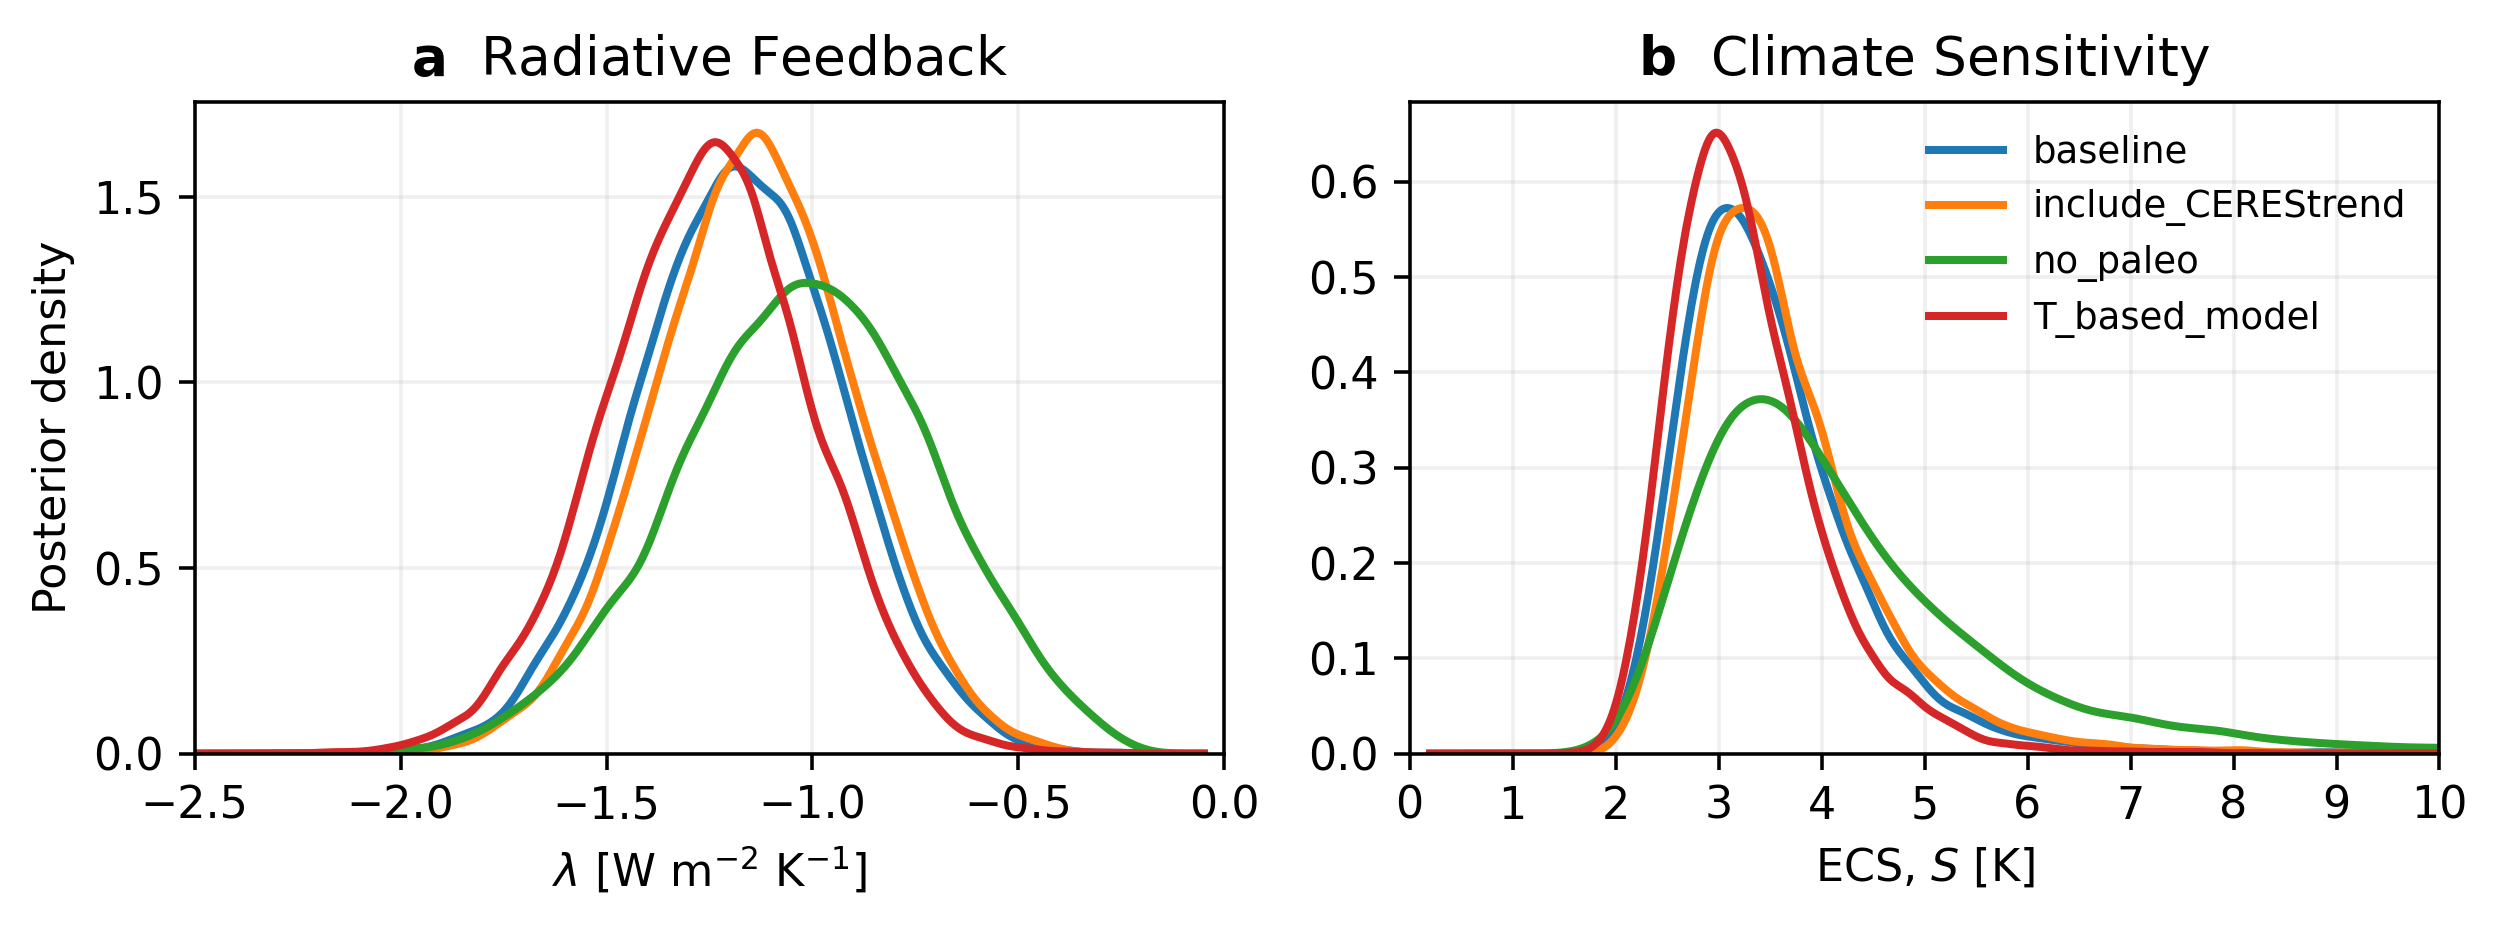

In [26]:
## Note: increase 'iter_sampling' as described above to reduce noise in the PDF estimate

## Plot lambda and ECS posterior densities for every completed scenario.
POSTERIOR_LAMBDA_GRID = np.linspace(-2.5, -0.05, 500)
POSTERIOR_S_GRID = np.linspace(0.2, 10.0, 500)

if results:
    fig, axs = plt.subplots(1, 2, figsize=(8.0, 3.0), dpi=160*2)
    for name, entry in results.items():
        axs[0].plot(
            POSTERIOR_LAMBDA_GRID,
            gaussian_kde(entry["lamb"])(POSTERIOR_LAMBDA_GRID),
            lw=1.8, label=name,
        )
        axs[1].plot(
            POSTERIOR_S_GRID,
            gaussian_kde(entry["S"])(POSTERIOR_S_GRID),
            lw=1.8, label=name,
        )

    axs[0].set(
        xlabel=r"$\lambda$ [W m$^{-2}$ K$^{-1}$]",
        ylabel="Posterior density",
        xlim=POSTERIOR_LAMBDA_GRID[[0, -1]],
        title=r"$\mathbf{a}$  Radiative Feedback",
    )
    axs[1].set(
        xlabel=r"ECS, $S$ [K]",
        xlim=POSTERIOR_S_GRID[[0, -1]],
        title=r"$\mathbf{b}$  Climate Sensitivity",
    )
    for ax in axs:
        ax.set_ylim(bottom=0)
        ax.grid(alpha=0.2)
        ## ax.set_title(ax.get_title(), loc="left")
    axs[1].legend(frameon=False, fontsize="small")

    axs[0].set_xlim(-2.5,0)
    axs[1].set_xlim(0,10)
    axs[1].set_xticks(np.arange(0,10+1,1))
    plt.tight_layout()
    plt.show()

## Likelihoods: visualizing each line of evidence

These diagnostics visualize the same selectable $N$-based or $T$-based convention and nuisance distributions as the Stan model. They are illustrative: Stan samples the joint posterior directly rather than constructing it by multiplying separately calculated curves. Set `score_T=True` in `calculate_likelihoods` to show the score-$T$ convention.

Each curve is normalized to its own maximum. The $S$ curves are calculated directly as $L(\mathrm{data}\mid S)$ while marginalizing the assessed $F_{2\times CO_2}$ uncertainty, so these are not transformed PDFs and receive no Jacobian. Joint paleo averages the product of the LGM and Pliocene contributions using shared $F_{2\times CO_2}$ draws and correlated paleo pattern-effect draws.


In [27]:
LIKELIHOOD_DEFAULTS = {
    ## Quick, smooth defaults; increase mc_draws/grid_points for publication.
    "lambda_min": -4.0,
    "lambda_max": -0.005,
    "S_min": 0.05,
    "S_max": 10.0,
    "grid_points": 260,
    "mc_draws": 30_000,
    "seed": 20250813,
}

INDIVIDUAL_EVIDENCE = ("Process", "Historical", "Trend", "LGM", "Pliocene")
PALEO_EVIDENCE = ("LGM", "Pliocene", "Joint paleo")
PROC_HIST_PALEO_EVIDENCE = ("Process", "Historical", "Joint paleo")

LIKELIHOOD_STYLES = {
    "Process": dict(color="navy", ls="-"),
    "Historical": dict(color="forestgreen", ls="-"),
    "Trend": dict(color="forestgreen", ls=":"),
    "LGM": dict(color="royalblue", ls="-"),
    "Pliocene": dict(color="darkorange", ls="-"),
    "Joint paleo": dict(color="firebrick", ls="-"),
}


def _relative_likelihood(values):
    values = np.asarray(values, dtype=float)
    peak = np.nanmax(values)
    if not np.isfinite(peak) or peak <= 0:
        raise ValueError("Likelihood curve has no finite positive values")
    return values / peak


def _normal_density_from_variance(observed, predicted_mean, variance):
    variance = np.maximum(np.asarray(variance, dtype=float), 1e-14)
    return np.exp(-0.5 * (observed - predicted_mean)**2 / variance) / np.sqrt(
        2 * np.pi * variance
    )


def _meinshausen_co2_sarf(co2_ppm, n2o_ppb=273.0):
    co2_ppm = np.asarray(co2_ppm, dtype=float)
    a1, b1, c1, d1 = -2.4785e-7, 7.5906e-4, -2.1492e-3, 5.2488
    co2_ref = 277.15
    co2_alpha_max = co2_ref - b1 / (2 * a1)
    alpha_prime = np.where(
        co2_ppm <= co2_ref,
        d1,
        np.where(
            co2_ppm < co2_alpha_max,
            d1 + a1 * (co2_ppm - co2_ref)**2 + b1 * (co2_ppm - co2_ref),
            d1 - b1**2 / (4 * a1),
        ),
    )
    return (alpha_prime + c1 * np.sqrt(n2o_ppb)) * np.log(co2_ppm / co2_ref)


def _plio_co2_f2x_ratio(co2_ppm, co2_pi):
    return (
        _meinshausen_co2_sarf(co2_ppm) - _meinshausen_co2_sarf(co2_pi)
    ) / (
        _meinshausen_co2_sarf(2 * co2_pi) - _meinshausen_co2_sarf(co2_pi)
    )

In [28]:
def calculate_likelihoods(
    label="baseline", *, input_updates=None, settings_updates=None,
    process_correlation=False, score_T=False,
):
    """Calculate marginal likelihoods on lambda and S grids.

    Use input_updates to change assessed parameters for one sensitivity version.
    Use settings_updates to change grids, sample count, or seed.
    Set process_correlation=True to apply rho_lambda_F2x to the Process curve.
    Set score_T=True to rearrange every energy budget and score temperature.
    """
    data = dict(BASE_INPUTS)
    input_updates = {} if input_updates is None else dict(input_updates)
    unknown_inputs = set(input_updates) - set(data)
    if unknown_inputs:
        raise KeyError(f"Unknown likelihood inputs: {sorted(unknown_inputs)}")
    data.update(input_updates)

    settings = dict(LIKELIHOOD_DEFAULTS)
    settings_updates = {} if settings_updates is None else dict(settings_updates)
    unknown_settings = set(settings_updates) - set(settings)
    if unknown_settings:
        raise KeyError(f"Unknown likelihood settings: {sorted(unknown_settings)}")
    settings.update(settings_updates)

    lambda_grid = np.linspace(
        settings["lambda_min"], settings["lambda_max"],
        int(settings["grid_points"]),
    )
    S_grid = np.linspace(
        settings["S_min"], settings["S_max"],
        int(settings["grid_points"]),
    )
    n = int(settings["mc_draws"])
    rng = np.random.default_rng(settings["seed"])

    ## Reuse common draws across every grid point and line of evidence.
    F2x = rng.normal(data["erf_2x"], data["sig_F2xCO2"], n)
    dlambda_hist = skewnorm.rvs(
        a=data["shape_dlambda"], loc=data["loc_dlambda"],
        scale=data["scale_dlambda"], size=n, random_state=rng,
    )
    dlambda_trend = rng.normal(
        data["mu_dlambda_trend"], data["sig_dlambda_trend"], n
    )

    paleo_dlambda_cov = np.array([
        [
            data["sig_dlambda_LGM"]**2,
            data["rho_dlambda_LGM_plio"]
            * data["sig_dlambda_LGM"] * data["sig_dlambda_plio"],
        ],
        [
            data["rho_dlambda_LGM_plio"]
            * data["sig_dlambda_LGM"] * data["sig_dlambda_plio"],
            data["sig_dlambda_plio"]**2,
        ],
    ])
    paleo_dlambda = rng.multivariate_normal(
        [data["mu_dlambda_LGM"], data["mu_dlambda_plio"]],
        paleo_dlambda_cov, size=n,
    )
    dlambda_lgm, dlambda_plio = paleo_dlambda.T
    f_co2_lgm = rng.normal(data["mu_f_CO2_LGM"], data["sig_f_CO2_LGM"], n)
    co2_plio = rng.normal(data["mu_CO2_plio"], data["sig_CO2_plio"], n)
    f_ch4 = rng.normal(data["mu_fCH4"], data["sig_fCH4"], n)
    f_co2_plio = _plio_co2_f2x_ratio(co2_plio, data["CO2_PI"])

    rho_process = data["rho_lambda_F2x"] if process_correlation else 0.0
    if not -1 < rho_process < 1:
        raise ValueError("rho_lambda_F2x must lie strictly between -1 and 1")

    hist_forcing_mean = (
        data["mu_F_CO2_hist"] * F2x / data["erf_2x"]
        + data["mu_F_anthro_aerosol_hist"] + data["mu_F_other_hist"]
    )
    hist_forcing_variance = (
        data["sig_F_anthro_aerosol_hist"]**2
        + data["sig_F_other_hist"]**2
    )

    def evaluate_at_lambda(lam, scalar_lambda, S_value=None):
        ## Process: the lambda marginal is unchanged by its F2x correlation.
        if scalar_lambda:
            process_like = norm.pdf(lam, data["mu_lambda"], data["sig_lambda"])
        else:
            ## Exact marginal for lambda = -F2x/S, including optional covariance.
            process_residual_mean = data["mu_lambda"] + data["erf_2x"] / S_value
            process_residual_variance = (
                data["sig_lambda"]**2
                + (data["sig_F2xCO2"] / S_value)**2
                + 2 * rho_process * data["sig_lambda"]
                * data["sig_F2xCO2"] / S_value
            )
            process_like = _normal_density_from_variance(
                0.0, process_residual_mean, process_residual_variance
            )

        beta_hist = lam - dlambda_hist
        hist_response_factor = np.abs(beta_hist) if score_T else 1.0
        hist_mean = hist_forcing_mean + data["mu_T_hist"] * beta_hist
        hist_variance = (
            data["sig_N_hist"]**2 + hist_forcing_variance
            + beta_hist**2 * data["sig_T_hist"]**2
        )
        historical_like = np.mean(
            hist_response_factor * _normal_density_from_variance(
                data["mu_N_hist"], hist_mean, hist_variance
            )
        )

        beta_trend = lam - dlambda_trend
        trend_response_factor = np.abs(beta_trend) if score_T else 1.0
        trend_forcing_mean = (
            data["mu_F_CO2_trend"] * F2x / data["erf_2x"]
            + data["mu_F_anthro_aerosol_trend"]
            + data["mu_F_other_trend"]
        )
        trend_mean = trend_forcing_mean + data["mu_T_trend"] * beta_trend
        trend_variance = (
            data["sig_N_trend"]**2
            + data["sig_F_anthro_aerosol_trend"]**2
            + data["sig_F_other_trend"]**2
            + beta_trend**2 * data["sig_T_trend"]**2
            - 2 * beta_trend * data["cov_TN_trend"]
        )
        trend_like = np.mean(
            trend_response_factor * _normal_density_from_variance(
                data["mu_N_trend"], trend_mean, trend_variance
            )
        )

        beta_lgm = lam - dlambda_lgm
        lgm_response_factor = np.abs(beta_lgm) if score_T else 1.0
        lgm_mean = (
            data["mu_F_other_LGM"] + f_co2_lgm * F2x
            + data["mu_T_LGM"] * beta_lgm
        )
        lgm_variance = (
            data["sig_N_LGM"]**2 + data["sig_F_other_LGM"]**2
            + beta_lgm**2 * data["sig_T_LGM"]**2
        )
        lgm_density = lgm_response_factor * _normal_density_from_variance(
            data["mu_N_LGM"], lgm_mean, lgm_variance
        )

        beta_plio = lam - dlambda_plio
        plio_response_factor = np.abs(beta_plio) if score_T else 1.0
        plio_mean = (
            f_co2_plio * F2x * (1 + f_ch4)
            + data["mu_F_plio_nonGHG"]
            + data["mu_T_plio"] * beta_plio
        )
        plio_variance = (
            data["sig_N_plio"]**2 + data["sig_F_plio_nonGHG"]**2
            + beta_plio**2 * data["sig_T_plio"]**2
        )
        plio_density = plio_response_factor * _normal_density_from_variance(
            data["mu_N_plio"], plio_mean, plio_variance
        )

        return {
            "Process": process_like,
            "Historical": historical_like,
            "Trend": trend_like,
            "LGM": np.mean(lgm_density),
            "Pliocene": np.mean(plio_density),
            ## Calculate this jointly rather than multiplying separately marginalized curves.
            "Joint paleo": np.mean(lgm_density * plio_density),
        }

    raw = {name: {"lambda": [], "S": []} for name in (*INDIVIDUAL_EVIDENCE, "Joint paleo")}
    for lam in lambda_grid:
        evaluated = evaluate_at_lambda(lam, scalar_lambda=True)
        for name, value in evaluated.items():
            raw[name]["lambda"].append(value)
    for S in S_grid:
        evaluated = evaluate_at_lambda(-F2x / S, scalar_lambda=False, S_value=S)
        for name, value in evaluated.items():
            raw[name]["S"].append(value)

    curves = {
        name: {
            axis: _relative_likelihood(values)
            for axis, values in axis_values.items()
        }
        for name, axis_values in raw.items()
    }
    return {
        "label": label, "data": data, "settings": settings,
        "process_correlation": process_correlation,
        "score_T": score_T,
        "lambda_grid": lambda_grid, "S_grid": S_grid,
        "curves": curves, "raw_curves": raw,
    }

In [29]:
def _format_likelihood_axes(axs, lambda_grid, S_grid, legend=True):
    axs[0].set(
        xlabel=r"$\lambda$ [W m$^{-2}$ K$^{-1}$]",
        ylabel="Relative likelihood", xlim=(-4,0),
        title=r"$\mathbf{a}$  Radiative Feedback",
    )
    axs[1].set(
        xlabel=r"$S$ [K]", xlim=(0,10),
        title=r"$\mathbf{b}$  Climate Sensitivity",
    )
    for ax in axs:
        ax.set_ylim(0, 1.05)
        ax.grid(alpha=0.2)
        ## ax.set_title(ax.get_title(), loc="left")
    if legend:
        axs[0].legend(frameon=False, fontsize="small")


def plot_likelihoods(result, evidence=INDIVIDUAL_EVIDENCE, *, title=None, save=None):
    """Plot selected evidence curves from one likelihood calculation."""
    fig, axs = plt.subplots(1, 2, figsize=(8.0, 3.0), dpi=160)
    for name in evidence:
        style = LIKELIHOOD_STYLES.get(name, {})
        axs[0].plot(
            result["lambda_grid"], result["curves"][name]["lambda"],
            lw=1.8, label=name, **style,
        )
        axs[1].plot(
            result["S_grid"], result["curves"][name]["S"],
            lw=1.8, label=name, **style,
        )
    _format_likelihood_axes(axs, result["lambda_grid"], result["S_grid"])
    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()
    if save is not None:
        fig.savefig(save, bbox_inches="tight")
    plt.show()
    return fig, axs


def plot_likelihood_versions(versions, evidence, *, title=None, save=None):
    """Overlay one line of evidence from several sensitivity versions."""
    fig, axs = plt.subplots(1, 2, figsize=(8.0, 3.0), dpi=160)
    for label, result in versions.items():
        axs[0].plot(
            result["lambda_grid"], result["curves"][evidence]["lambda"],
            lw=1.8, label=label,
        )
        axs[1].plot(
            result["S_grid"], result["curves"][evidence]["S"],
            lw=1.8, label=label,
        )
    first = next(iter(versions.values()))
    _format_likelihood_axes(axs, first["lambda_grid"], first["S_grid"])
    if title is None:
        title = f"{evidence} likelihood sensitivity"
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    if save is not None:
        fig.savefig(save, bbox_inches="tight")
    plt.show()
    return fig, axs

### Baseline likelihood calculation

All five individual diagnostics are calculated whether or not a particular line is enabled in a Stan scenario. The Process-correlation setting follows `BASELINE_SWITCHES`.


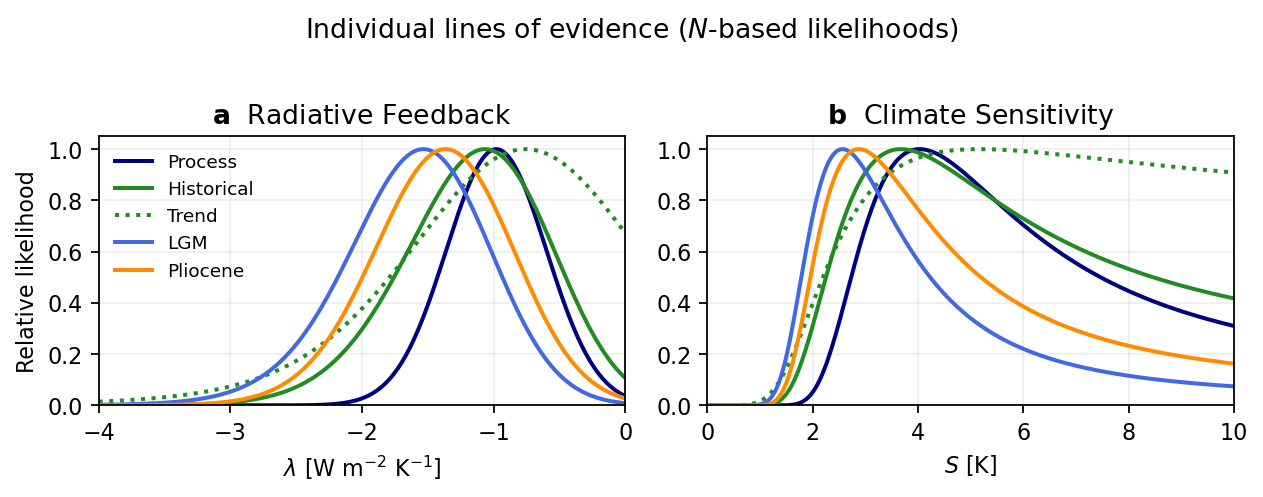

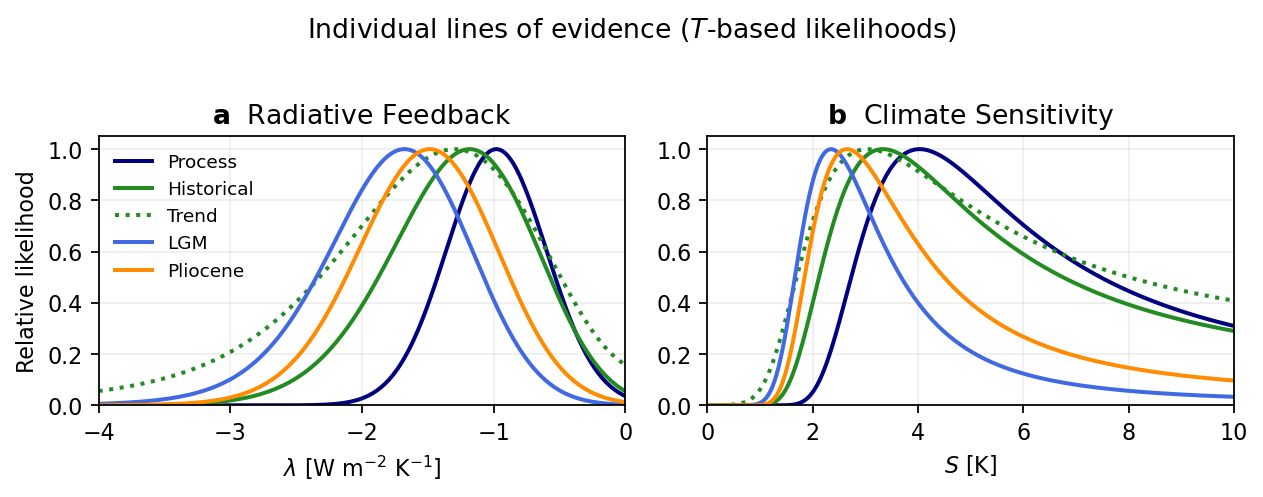

In [30]:
print('Revised N-based likelihoods')
## Baseline (N-based)
likelihood_results = {}
likelihood_results["baseline"] = calculate_likelihoods(
    "baseline",
    score_T=0,
)

plot_likelihoods(
    likelihood_results["baseline"],
    evidence=INDIVIDUAL_EVIDENCE,
    title="Individual lines of evidence ($N$-based likelihoods)",
)
plt.show()

print('SW20 T-based likelihoods')
## T-based version
likelihood_results_scoreT = {}
likelihood_results_scoreT["baseline"] = calculate_likelihoods(
    "baseline",
    score_T=1,
)
plot_likelihoods(
    likelihood_results_scoreT["baseline"],
    evidence=INDIVIDUAL_EVIDENCE,
    title="Individual lines of evidence ($T$-based likelihoods)",
)
plt.show()

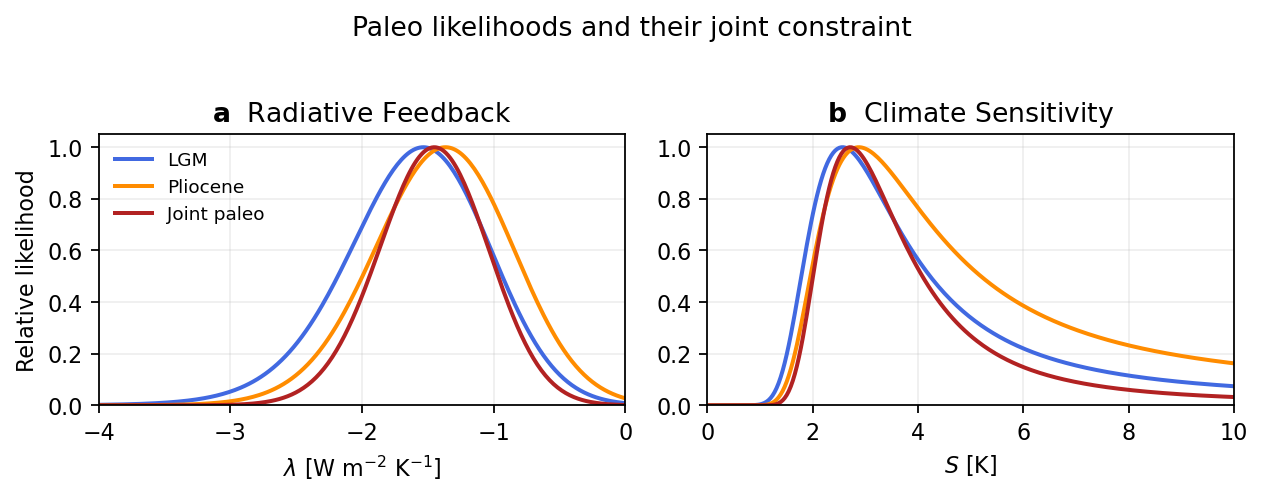

In [31]:
## Calculate Joint paleo with shared F_2xCO2 draws and the assessed
## LGM-Pliocene pattern-effect correlation. It is not L_LGM * L_Pliocene.
plot_likelihoods(
    likelihood_results["baseline"],
    evidence=PALEO_EVIDENCE,
    title="Paleo likelihoods and their joint constraint",
)
plt.show()

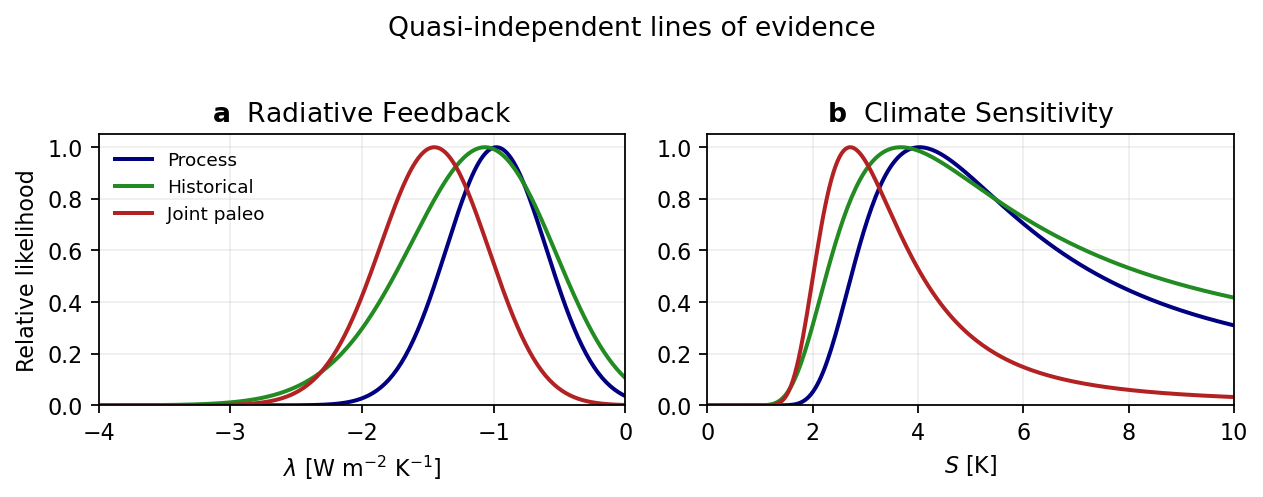

In [32]:
## three quasi-independent lines of evidence
plot_likelihoods(
    likelihood_results["baseline"],
    evidence=PROC_HIST_PALEO_EVIDENCE,
    title="Quasi-independent lines of evidence",
)
plt.show()